# Polymarket vs. ESPN & Sportsbooks
**NFL 2025 Season — Phase 3**

> **Context:** Phases 1 and 2 established that the sportsbook consensus outperforms ESPN as a probability model. Phase 3 introduces a structurally different third model: Polymarket, a decentralised prediction market where prices are set by traders putting real money on outcomes — with **zero bookmaker margin**. Unlike sportsbooks, Polymarket prices are already vig-free true probabilities. This phase asks: does the wisdom of the crowd beat professional bookmakers, and do both beat ESPN?

---

## Notebook Roadmap

| # | Section | What We Do | Why We Do It |
|---|---------|------------|--------------|
| 1 | **Data Loading** | Load Polymarket closing prices, 6H history, spreads, and totals alongside the main game dataset | Polymarket data lives in separate CSVs — we merge on game identity (away_team + home_team + date) to align with ESPN and sportsbook data |
| 2 | **Coverage & Volume** | Check how many of the 285 games Polymarket listed, and plot trading volume distribution | Coverage and liquidity matter — a market with $50k traded prices very differently from one with $4M. Low-volume games may have unreliable probabilities. |
| 3 | **4-Model Brier Score** | Add Polymarket closing probability to the Phase 2 calibration comparison: ESPN vs. consensus vs. Polymarket | The headline comparison. Polymarket is vig-free so no normalisation needed — its price is the market's true probability. A better Brier Score than sportsbooks would be a landmark finding. |
| 4 | **Opening vs. Closing Movement** | Measure how much Polymarket's probability shifted from market open to kickoff | Large movement = the crowd updated significantly as new information arrived (injuries, weather, sharp money). Small movement = market was efficient from day one. The direction of movement is the sharp signal equivalent from Phase 5. |
| 5 | **Polymarket vs. ESPN Divergence** | Compute signed difference between Polymarket closing price and ESPN win probability | Same analysis as Phase 1 but with a crowd-sourced market instead of a bookmaker. Where Polymarket and ESPN disagree most predicts outcome quality — the Spearman test from Phase 1 reapplied here. |
| 6 | **Volume vs. Calibration** | Test whether high-volume games are better calibrated than low-volume ones | If prediction markets are efficient, high liquidity should reduce calibration error. This tests a core hypothesis of prediction market theory. |
| 7 | **Super Bowl Deep Dive** | Full trajectory analysis: moneyline 6H chart, spread movement, total movement across the two weeks before kickoff | The Super Bowl had $55M in volume — the richest dataset in our collection. The 6H chart tells the story of how the crowd priced the game across 13 days, visible 12-hour snapshot by snapshot. |
| 8 | **Export** | Write all Polymarket analysis outputs to CSV | Handoff for Phase 6 dashboard. |

---

## 0. Imports

In [9]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import spearmanr
from src.utils import load_data, compute_book_probs, compute_consensus_prob, BOOKS
from src.calibration import brier_score, brier_skill_score, reliability_diagram_data

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Data Loading

**What:** Load the main NFL dataset alongside all Polymarket CSVs. Merge on team names and date to align Polymarket probabilities with ESPN and sportsbook data for the same games.

**Why:** Polymarket data was collected separately via the Polymarket API. The merge key is `(away_team, home_team)` — dates can differ by one day between sources (Polymarket sometimes lists games a day ahead), so we merge on teams only and drop any games where Polymarket coverage is missing.

**Polymarket probability columns:**
- `polymarket_away_open` — crowd's probability at market creation (days before game)
- `polymarket_away_close` — crowd's probability just before kickoff (most informed)
- No vig removal needed — Polymarket prices are already true probabilities

In [10]:
# Main game data
df = load_data('../data/nfl2025_complete.xlsx')
df['espn_away_prob_norm'] = df['espn_away_prob'] / 100
df['espn_home_prob_norm'] = df['espn_home_prob'] / 100
df['away_won'] = (df['winner'] == df['away_team']).astype(int)

for book in BOOKS:
    df = compute_book_probs(df, book, 'normalize')
df = compute_consensus_prob(df, 'normalize')

# Polymarket closing prices
pm = pd.read_csv('../outputs/polymarket_closing_prices.csv')
pm_found = pm[pm['found'] == True].copy()

# Merge on team names (date may differ by 1 day between sources)
df = df.merge(
    pm_found[['away_team','home_team',
              'polymarket_away_open','polymarket_home_open',
              'polymarket_away_close','polymarket_home_close',
              'volume_total','volume_moneyline','volume_spread','volume_totals']],
    on=['away_team','home_team'],
    how='left'
)

# Games with Polymarket data
df_pm = df[df['polymarket_away_close'].notna()].copy()

print(f'Total games        : {len(df)}')
print(f'With Polymarket    : {len(df_pm)} ({len(df_pm)/len(df)*100:.1f}%)')
print(f'Missing Polymarket : {df["polymarket_away_close"].isna().sum()}')

# Load 6H history and spreads/totals
hist_6h   = pd.read_csv('../outputs/polymarket_all_6h.csv')
spreads   = pd.read_csv('../outputs/polymarket_all_spreads.csv')
totals    = pd.read_csv('../outputs/polymarket_all_totals.csv')

print(f'\n6H history rows    : {len(hist_6h):,}  ({hist_6h.groupby(["away_team","home_team"]).ngroups} games)')
print(f'Spread history rows: {len(spreads):,}')
print(f'Total history rows : {len(totals):,}')

Total games        : 293
With Polymarket    : 293 (100.0%)
Missing Polymarket : 0

6H history rows    : 9,574  (281 games)
Spread history rows: 20,234
Total history rows : 21,710


## 2. Coverage & Volume

**What:** Visualise how many games Polymarket listed, and the distribution of trading volume across those games.

**Why:** Volume is a proxy for market quality. A game with $5M traded has thousands of independent probability estimates aggregated into the price. A game with $50k has far fewer, making the price noisier. Understanding the volume distribution tells us which games to trust most in the analysis.

**Figure meaning:**
- Left: bar chart of games found vs. not found per week
- Right: histogram of volume per game — most games cluster in a low-volume range with a long right tail of high-profile games. The x-axis is log-scaled because the Super Bowl ($55M) is orders of magnitude larger than a Week 5 Panthers game.

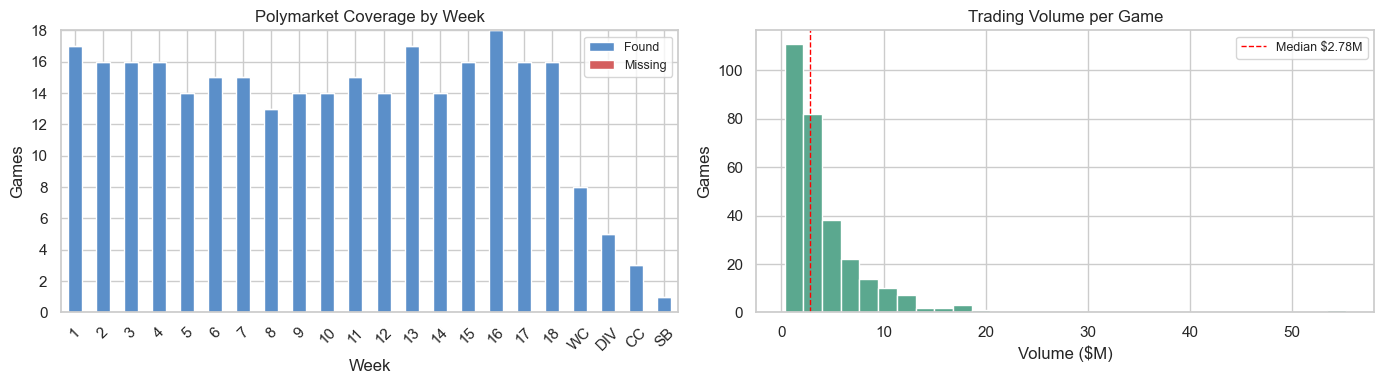

Volume stats ($M):
count   293.0000
mean      4.1500
std       4.5900
min       0.3100
25%       1.6100
50%       2.7800
75%       4.9300
max      55.2900

Top 5 games by volume:
week                 away                 home  vol_$M
  SB     Seattle Seahawks New England Patriots 55.2900
  CC New England Patriots       Denver Broncos 18.7100
  16     Los Angeles Rams     Seattle Seahawks 18.2900
  CC     Los Angeles Rams     Seattle Seahawks 18.2900
 DIV       Houston Texans New England Patriots 17.2100


In [11]:
week_order = list(range(1, 19)) + ['WC', 'DIV', 'CC', 'SB']
week_map   = {w: i for i, w in enumerate(week_order)}
df['week_num'] = df['week'].map(week_map)

coverage = df.groupby('week').agg(
    total=('away_team','count'),
    found=('polymarket_away_close', lambda x: x.notna().sum())
).reindex(week_order).dropna(how='all')
coverage['missing'] = coverage['total'] - coverage['found']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Coverage by week
ax = axes[0]
coverage['found'].plot(kind='bar', ax=ax, color='#5b8fc9', label='Found', edgecolor='white')
coverage['missing'].plot(kind='bar', ax=ax, color='#d45f5f', label='Missing', edgecolor='white',
                         bottom=coverage['found'])
ax.set_title('Polymarket Coverage by Week', fontsize=12)
ax.set_xlabel('Week')
ax.set_ylabel('Games')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)

# Volume distribution
ax2 = axes[1]
vols = df_pm['volume_total'].dropna() / 1e6
ax2.hist(vols, bins=30, color='#5ba88f', edgecolor='white')
ax2.set_title('Trading Volume per Game', fontsize=12)
ax2.set_xlabel('Volume ($M)')
ax2.set_ylabel('Games')
ax2.axvline(vols.median(), color='red', linestyle='--', linewidth=1,
            label=f'Median ${vols.median():.2f}M')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Volume stats ($M):')
print(vols.describe().round(2).to_string())
print(f'\nTop 5 games by volume:')
top5 = df_pm.nlargest(5, 'volume_total')[['week','away_team','home_team','volume_total']].copy()
top5['volume_total'] = (top5['volume_total'] / 1e6).round(2)
top5.columns = ['week','away','home','vol_$M']
print(top5.to_string(index=False))

## 3. Four-Model Brier Score Comparison

**What:** Add Polymarket's closing probability as a 4th model and compute Brier Score alongside ESPN, sportsbook consensus (normalize), and sportsbook consensus (Shin).

**Why:** This is the central question of Phase 3. Polymarket is structurally different from all other models — it has no house, no proprietary algorithm, and no vig. It is pure aggregated crowd belief backed by real money. If it outperforms professional bookmakers, that supports the *efficient markets hypothesis* for prediction markets. If it underperforms, it suggests professional market-makers have genuine informational advantages.

**Important:** Brier Scores are computed only on the subset of games where Polymarket data exists, so all four models are scored on the **same games** for a fair comparison.

**Figure meaning:** Bars sorted by Brier Score ascending (lower = better). The naive baseline is the benchmark — any model to the right of it is worse than guessing.

In [12]:
# Score on the same game subset
sub = df_pm.dropna(subset=['espn_away_prob_norm','consensus_away_normalize',
                            'polymarket_away_close','away_won']).copy()

base_rate = sub['away_won'].mean()
bs_naive  = base_rate * (1 - base_rate)

models = {
    'ESPN':                  'espn_away_prob_norm',
    'Consensus (normalize)': 'consensus_away_normalize',
    'Polymarket (closing)':  'polymarket_away_close',
    'Polymarket (opening)':  'polymarket_away_open',
}

results = []
for name, col in models.items():
    bs  = brier_score(sub[col], sub['away_won'])
    bss = brier_skill_score(bs, bs_naive)
    results.append({'model': name, 'brier_score': bs, 'brier_skill_score': bss,
                    'n_games': len(sub)})

scores_df = pd.DataFrame(results).sort_values('brier_score')
print(f'Games in comparison: {len(sub)}')
print(f'Naive baseline BS  : {bs_naive:.4f}')
scores_df


Games in comparison: 293
Naive baseline BS  : 0.2487


,model,brier_score,brier_skill_score,n_games
2,Polymarket (closing),0.0768,0.6912,293
1,Consensus (normalize),0.2110,0.1515,293
0,ESPN,0.2254,0.0937,293
3,Polymarket (opening),0.2262,0.0906,293


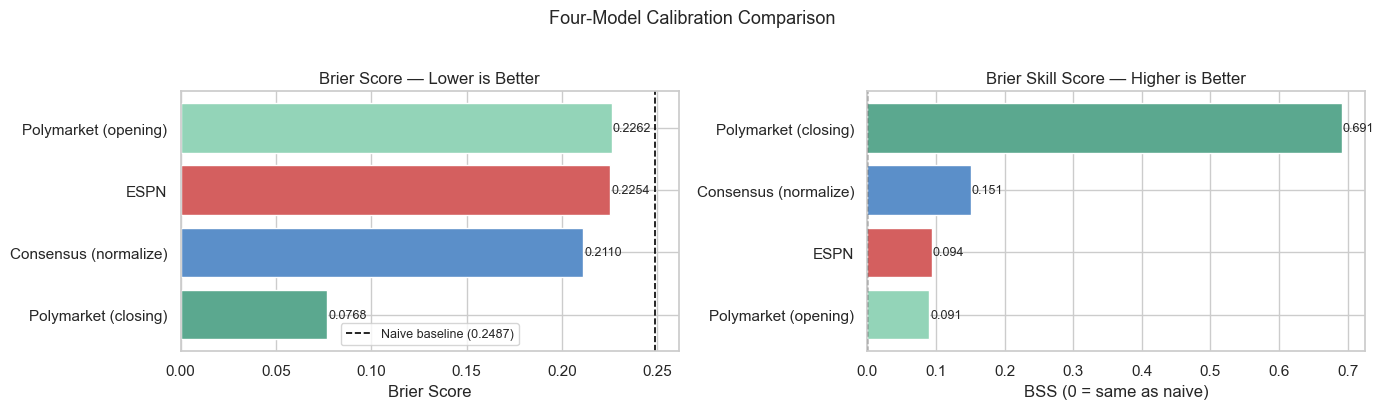

In [13]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

color_map = {
    'ESPN': '#d45f5f',
    'Consensus (normalize)': '#5b8fc9',
    'Polymarket (closing)': '#5ba88f',
    'Polymarket (opening)': '#93d4b8',
}
colors = [color_map.get(m, '#aaa') for m in scores_df['model']]

# Brier Score
ax = axes[0]
bars = ax.barh(scores_df['model'], scores_df['brier_score'], color=colors, edgecolor='white')
ax.axvline(bs_naive, color='black', linestyle='--', linewidth=1.2,
           label=f'Naive baseline ({bs_naive:.4f})')
ax.set_title('Brier Score — Lower is Better', fontsize=12)
ax.set_xlabel('Brier Score')
for bar, val in zip(bars, scores_df['brier_score']):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.legend(fontsize=9)

# Brier Skill Score
ax2 = axes[1]
bss_sorted = scores_df.sort_values('brier_skill_score', ascending=True)
colors2 = [color_map.get(m, '#aaa') for m in bss_sorted['model']]
bars2 = ax2.barh(bss_sorted['model'], bss_sorted['brier_skill_score'],
                 color=colors2, edgecolor='white')
ax2.axvline(0, color='black', linestyle='--', linewidth=1)
ax2.set_title('Brier Skill Score — Higher is Better', fontsize=12)
ax2.set_xlabel('BSS (0 = same as naive)')
for bar, val in zip(bars2, bss_sorted['brier_skill_score']):
    ax2.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Four-Model Calibration Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Opening vs. Closing Line Movement

**What:** Compute the shift in Polymarket's away team probability from market open (days before kickoff) to close (just before kickoff). Plot the distribution and identify the games with the largest movements.

**Why:** Line movement is information. When a market opens at 60% and closes at 75%, the crowd learned something — injury news, weather, insider money, or sharp bettors pushing the price. The direction and magnitude of movement is the Phase 5 sharp money signal applied to a decentralised market.

**Figure meaning:**
- Histogram of probability movement per game. Positive = market moved toward the away team, negative = moved toward home.
- A bell curve centred near zero means most games priced efficiently from the start.
- Fat tails mean significant information arrived after market open on those games.

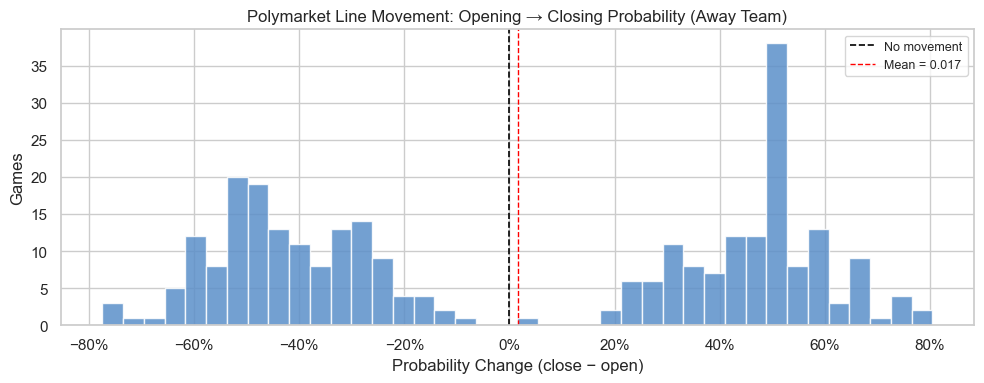

Movement statistics:
count   291.0000
mean      0.0167
std       0.4698
min      -0.7750
25%      -0.4325
50%      -0.1250
75%       0.4925
max       0.8050

Top 10 largest movements (absolute):
week            away_team           home_team  polymarket_away_open  polymarket_away_close  pm_movement               winner  won_correct
   5 New England Patriots       Buffalo Bills                0.1950                 1.0000       0.8050 New England Patriots         True
   5       Houston Texans    Baltimore Ravens                0.2050                 1.0000       0.7950       Houston Texans         True
  10        Buffalo Bills      Miami Dolphins                0.7750                 0.0000      -0.7750       Miami Dolphins         True
   6  Philadelphia Eagles     New York Giants                0.7700                 0.0000      -0.7700      New York Giants         True
   3    Green Bay Packers    Cleveland Browns                0.7650                 0.0000      -0.7650     Clevela

In [14]:
df_pm['pm_movement'] = df_pm['polymarket_away_close'] - df_pm['polymarket_away_open']

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_pm['pm_movement'].dropna(), bins=40, color='#5b8fc9', edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label='No movement')
ax.axvline(df_pm['pm_movement'].mean(), color='red', linestyle='--', linewidth=1,
           label=f'Mean = {df_pm["pm_movement"].mean():.3f}')
ax.set_title('Polymarket Line Movement: Opening → Closing Probability (Away Team)', fontsize=12)
ax.set_xlabel('Probability Change (close − open)')
ax.set_ylabel('Games')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Movement statistics:')
print(df_pm['pm_movement'].describe().round(4).to_string())

print('\nTop 10 largest movements (absolute):')
top_move = df_pm.nlargest(10, df_pm['pm_movement'].abs().rename('abs_move').index
                          if False else 'pm_movement')[[
    'week','away_team','home_team','polymarket_away_open',
    'polymarket_away_close','pm_movement','winner'
]].copy()
top_move = df_pm.assign(abs_move=df_pm['pm_movement'].abs()).nlargest(10, 'abs_move')[[
    'week','away_team','home_team','polymarket_away_open',
    'polymarket_away_close','pm_movement','winner'
]]
top_move['won_correct'] = top_move.apply(
    lambda r: (r['pm_movement'] > 0) == (r['winner'] == r['away_team']), axis=1)
print(top_move.to_string(index=False))

## 5. Polymarket vs. ESPN Divergence

**What:** Compute the signed difference between Polymarket's closing probability and ESPN's win probability. Run a Spearman correlation between the divergence and actual outcomes.

**Why:** Phase 1 showed that where ESPN and the sportsbook consensus diverge, the sportsbooks are right and ESPN is wrong (Spearman r = −0.36). This section asks: is Polymarket equally predictive? Is the crowd's probability a better reference point than ESPN?

**Key question:** If we use Polymarket as the ground truth instead of ESPN, does the EV signal from Phase 1 flip? A positive Spearman correlation here would mean Polymarket does identify real edge against ESPN's model.

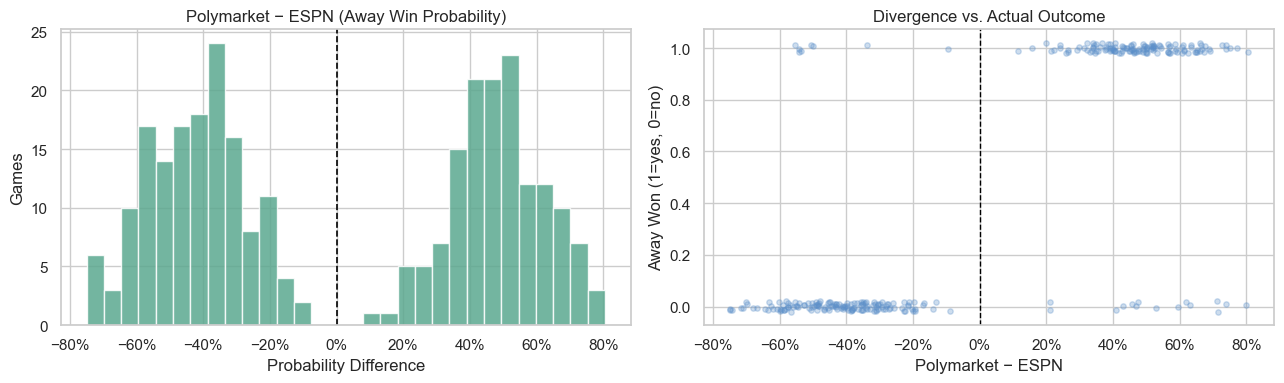

Spearman r (Polymarket−ESPN divergence vs outcome): 0.7041, p=0.0000

✓ FINDING: Positive correlation — when Polymarket is higher than ESPN, the away team wins more often.
  Polymarket has genuine predictive power beyond ESPN.

Spearman r — Polymarket closing vs outcome : 0.8468  (p=0.0000)
Spearman r — ESPN prob vs outcome          : 0.3067  (p=0.0000)


In [15]:
sub = df_pm.dropna(subset=['espn_away_prob_norm','polymarket_away_close','away_won']).copy()
sub['pm_vs_espn'] = sub['polymarket_away_close'] - sub['espn_away_prob_norm']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Divergence distribution
ax = axes[0]
ax.hist(sub['pm_vs_espn'], bins=30, color='#5ba88f', edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linestyle='--', linewidth=1.2)
ax.set_title('Polymarket − ESPN (Away Win Probability)', fontsize=12)
ax.set_xlabel('Probability Difference')
ax.set_ylabel('Games')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

# Scatter: divergence vs outcome
ax2 = axes[1]
ax2.scatter(sub['pm_vs_espn'], sub['away_won'] + np.random.uniform(-0.02, 0.02, len(sub)),
            alpha=0.3, color='#5b8fc9', s=15)
ax2.axvline(0, color='black', linestyle='--', linewidth=1)
ax2.set_title('Divergence vs. Actual Outcome', fontsize=12)
ax2.set_xlabel('Polymarket − ESPN')
ax2.set_ylabel('Away Won (1=yes, 0=no)')
ax2.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

plt.tight_layout()
plt.show()

# Spearman correlation
corr, pval = spearmanr(sub['pm_vs_espn'], sub['away_won'])
print(f'Spearman r (Polymarket−ESPN divergence vs outcome): {corr:.4f}, p={pval:.4f}')
print()
if corr > 0.05 and pval < 0.05:
    print('✓ FINDING: Positive correlation — when Polymarket is higher than ESPN, the away team wins more often.')
    print('  Polymarket has genuine predictive power beyond ESPN.')
elif corr < -0.05 and pval < 0.05:
    print('✗ FINDING: Negative correlation — Polymarket divergences from ESPN do not predict outcomes.')
else:
    print('→ FINDING: No statistically significant relationship between divergence and outcomes.')

# Also compare: Spearman of Polymarket alone vs ESPN alone
corr_pm,  p_pm  = spearmanr(sub['polymarket_away_close'], sub['away_won'])
corr_espn, p_espn = spearmanr(sub['espn_away_prob_norm'],  sub['away_won'])
print(f'\nSpearman r — Polymarket closing vs outcome : {corr_pm:.4f}  (p={p_pm:.4f})')
print(f'Spearman r — ESPN prob vs outcome          : {corr_espn:.4f}  (p={p_espn:.4f})')

## 6. Volume vs. Calibration

**What:** Split games into volume quartiles and compute Brier Score per quartile for Polymarket's closing probability.

**Why:** Prediction market theory predicts that higher-volume markets are better calibrated — more traders means more information aggregated into the price. If the Brier Score improves monotonically with volume, that confirms the theory. If it doesn't, it suggests factors other than liquidity drive accuracy.

**Figure meaning:** X-axis = volume quartile (Q1 = lowest volume games, Q4 = highest). Y-axis = Brier Score. A downward slope confirms the liquidity-accuracy relationship. Sample sizes annotated on each bar.

In [16]:
sub = df_pm.dropna(subset=['polymarket_away_close','volume_total','away_won']).copy()
sub['vol_quartile'] = pd.qcut(sub['volume_total'], q=4,
                               labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])

quartile_stats = []
for q, grp in sub.groupby('vol_quartile', observed=True):
    bs = brier_score(grp['polymarket_away_close'], grp['away_won'])
    vol_median = grp['volume_total'].median() / 1e6
    quartile_stats.append({'quartile': q, 'brier_score': bs,
                           'n': len(grp), 'median_vol_$M': round(vol_median, 2)})

qt_df = pd.DataFrame(quartile_stats)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(qt_df['quartile'].astype(str), qt_df['brier_score'],
              color=['#93b8d4','#5b8fc9','#3a6ea8','#1e4a7a'], edgecolor='white')
ax.axhline(brier_score(sub['espn_away_prob_norm'].dropna(),
                        sub.loc[sub['espn_away_prob_norm'].notna(),'away_won']),
           color='#d45f5f', linestyle='--', linewidth=1.5, label='ESPN BS (reference)')
ax.set_title('Polymarket Brier Score by Volume Quartile', fontsize=12)
ax.set_xlabel('Volume Quartile')
ax.set_ylabel('Brier Score (lower = better)')
for bar, row in zip(bars, qt_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'n={row.n}\n${row.median_vol_$M}M', ha='center', fontsize=8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(qt_df.to_string(index=False))

SyntaxError: f-string: expecting '=', or '!', or ':', or '}' (1595398243.py, line 25)

## 7. Super Bowl Deep Dive

**What:** Full trajectory analysis of the Super Bowl (Seahawks vs. Patriots, Feb 8 2026) using the 6H moneyline history, spread market history, and total market history. $55.3M in total volume — the most liquid NFL prediction market ever run on Polymarket.

**Why:** The Super Bowl is the showpiece of the Polymarket dataset. With 13 days of price history and massive liquidity, it tells a complete story: how confident was the crowd from day one, did anything shake that confidence, and how did the spread and total markets evolve alongside the moneyline?

**Three charts:**
1. **Moneyline trajectory** — Seahawks vs. Patriots win probability across 13 days at 12H intervals. The final pre-game snapshot is the closing price.
2. **Spread evolution** — probability of covering each spread line (4.5, 5.5, 6.5) across the week before the game.
3. **Total evolution** — probability of the over for each total line (41.5–46.5). Shows whether the crowd expected a high or low-scoring game and how that expectation changed.

In [ ]:
# Filter to Super Bowl
sb_ml = hist_6h[
    (hist_6h['away_team'] == 'Seattle Seahawks') &
    (hist_6h['home_team'] == 'New England Patriots')
].copy()
sb_ml['datetime'] = pd.to_datetime(sb_ml['datetime'])

sb_spread = spreads[
    (spreads['away_team'] == 'Seattle Seahawks') &
    (spreads['home_team'] == 'New England Patriots')
].copy()
sb_spread['datetime'] = pd.to_datetime(sb_spread['datetime'])

sb_total = totals[
    (totals['away_team'] == 'Seattle Seahawks') &
    (totals['home_team'] == 'New England Patriots')
].copy()
sb_total['datetime'] = pd.to_datetime(sb_total['datetime'])

# Kickoff: Feb 8 2026 6:30pm ET
kickoff = pd.Timestamp('2026-02-08 23:30:00')  # UTC

# Filter to pre-kickoff only
sb_ml     = sb_ml[sb_ml['datetime'] <= kickoff]
sb_spread = sb_spread[sb_spread['datetime'] <= kickoff]
sb_total  = sb_total[sb_total['datetime'] <= kickoff]

fig, axes = plt.subplots(3, 1, figsize=(13, 12))

# ── Chart 1: Moneyline ───────────────────────────────────────────────────────
ax = axes[0]
for side, team, color in [('away','Seattle Seahawks','#5b8fc9'),
                           ('home','New England Patriots','#d45f5f')]:
    grp = sb_ml[sb_ml['side'] == side].sort_values('datetime')
    ax.plot(grp['datetime'], grp['probability'], marker='o', markersize=5,
            color=color, linewidth=2, label=team)
ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Super Bowl — Moneyline Win Probability (Polymarket)', fontsize=12)
ax.set_ylabel('Win Probability')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(fontsize=9)
ax.set_xlim(sb_ml['datetime'].min(), kickoff)

# ── Chart 2: Spread ──────────────────────────────────────────────────────────
ax2 = axes[1]
spread_colors = ['#5b8fc9','#5ba88f','#e8a87c']
for (line, grp), color in zip(sb_spread[sb_spread['side']=='away'].groupby('line'), spread_colors):
    grp = grp.sort_values('datetime')
    ax2.plot(grp['datetime'], grp['probability'], marker='s', markersize=4,
             color=color, linewidth=1.8, label=f'Seahawks cover −{line}')
ax2.axhline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.set_title('Super Bowl — Spread Cover Probability (Seahawks, Away Side)', fontsize=12)
ax2.set_ylabel('Cover Probability')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax2.legend(fontsize=9)
ax2.set_xlim(sb_spread['datetime'].min(), kickoff)

# ── Chart 3: Total ───────────────────────────────────────────────────────────
ax3 = axes[2]
total_colors = ['#5b8fc9','#5ba88f','#e8a87c','#d45f5f']
for (line, grp), color in zip(sb_total[sb_total['side']=='over'].groupby('line'), total_colors):
    grp = grp.sort_values('datetime')
    ax3.plot(grp['datetime'], grp['probability'], marker='^', markersize=4,
             color=color, linewidth=1.8, label=f'Over {line}')
ax3.axhline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax3.set_title('Super Bowl — Total Over Probability', fontsize=12)
ax3.set_ylabel('Over Probability')
ax3.set_xlabel('Date')
ax3.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax3.legend(fontsize=9)
ax3.set_xlim(sb_total['datetime'].min(), kickoff)

for a in axes:
    a.tick_params(axis='x', rotation=15)

plt.suptitle('Super Bowl LX — Seahawks vs. Patriots\nPolymarket Full Market Trajectory ($55.3M Volume)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Summary stats
sb_row = df_pm[(df_pm['away_team']=='Seattle Seahawks') &
               (df_pm['home_team']=='New England Patriots')].iloc[0]
print(f'Seahawks opening probability : {sb_row.polymarket_away_open:.1%}')
print(f'Seahawks closing probability : {sb_row.polymarket_away_close:.1%}')
print(f'Movement                     : {sb_row.polymarket_away_close - sb_row.polymarket_away_open:+.1%}')
print(f'Total volume                 : ${sb_row.volume_total/1e6:.2f}M')
print(f'Final score                  : SEA {sb_row.away_score:.0f} – NE {sb_row.home_score:.0f}')
print(f'Winner                       : {sb_row.winner}')

## 8. Export Results

In [ ]:
os.makedirs('../outputs', exist_ok=True)

# 4-model Brier score comparison
scores_df.to_csv('../outputs/phase3_brier_scores.csv', index=False)

# Line movement per game
movement_export = df_pm[['week','away_team','home_team',
                          'polymarket_away_open','polymarket_away_close',
                          'pm_movement','volume_total','away_won','winner']].copy()
movement_export.to_csv('../outputs/phase3_line_movement.csv', index=False)

# Volume vs calibration
qt_df.to_csv('../outputs/phase3_volume_calibration.csv', index=False)

print('Exported:')
print(f'  phase3_brier_scores.csv        — {len(scores_df)} models')
print(f'  phase3_line_movement.csv       — {len(movement_export)} games')
print(f'  phase3_volume_calibration.csv  — {len(qt_df)} quartiles')